Exercise 10.1

- Write a library of functions to determine the parameter τ of an exponential distribution from a list of numbers filled with pseudo-random numbers distributed according to an exponential probability density distribution.
- Compare the result obtained with the mean of the numbers saved in the list.
- How does the result depend on the initial interval passed to the sezione_aurea_max_LL function?


In [24]:
from generator import generate_exp
from stats import stats
from likelihood import loglikelihood, exp_pdf, sezioneAureaMax_LL
tau = 2
N = 1000
randlist = generate_exp(tau, N, seed = 0.)
my_stats = stats(randlist)
mean = my_stats.mean()
tau_expected = sezioneAureaMax_LL (loglikelihood, exp_pdf, randlist, 0.5, 5)  
print('tau_true = ', mean)
print('tau_max = ', tau_expected)

tau_true =  1.9750727340549328
tau_max =  1.9750688530848448


Exercise 10.2
- Plot the profile of the likelihood function and the point identified as its maximum.


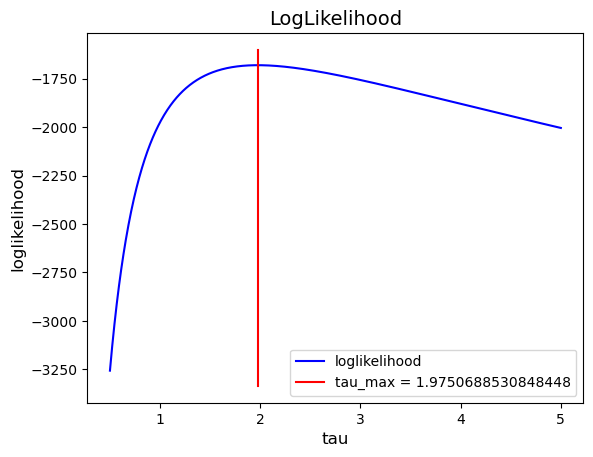

In [25]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots()
x_axis = np.linspace(0.5, 5., 1000)
y_axis = np.arange(0., x_axis.size)
for i in range(x_axis.size):
    y_axis[i] = loglikelihood(x_axis[i], exp_pdf, randlist)
plt.plot( x_axis, y_axis, color = 'b', label = 'loglikelihood')
plt.plot( [tau_expected, tau_expected], ax.get_ylim(), color = 'r', label = 'tau_max = ' + str(tau_expected)) 
ax.set_title('LogLikelihood', size = 14)
ax.set_xlabel('tau', size = 12)
ax.set_ylabel('loglikelihood', size = 12)
ax.legend()
plt.show()

Exercise 10.3
- Modify the sezione_aurea_max_LL function, adding the printing of the interval endpoint values at each iteration, to observe the narrowing of the interval during program execution.


In [26]:
def sezioneAureaMax_LL1 (g,pdf,sample,xmin,xmax,prec = 0.0001):
    r = 0.618
    print('initial interval : ' + str(xmin) + '-' + str(xmax) )
    while (xmax-xmin) > prec :
        x1 = xmin + (1-r) *( xmax-xmin)
        x2 = xmin + r * (xmax-xmin)
        if g(x1,exp_pdf,sample) < g(x2,exp_pdf,sample) :
            xmin = x1
            print('sequence of the interval : ' + str(xmin) + '-' + str(xmax) )
        else : 
            xmax = x2
            print('sequence of the interval : ' + str(xmin) + '-' + str(xmax) )
    return (xmax + xmin) * 0.5   

In [27]:
g = loglikelihood
pdf = exp_pdf
sample = randlist
xmin = 0.5
xmax = 5.
sezioneAureaMax_LL1(g,pdf,sample,xmin,xmax)

initial interval : 0.5-5.0
sequence of the interval : 0.5-3.281
sequence of the interval : 1.5623420000000001-3.281
sequence of the interval : 1.5623420000000001-2.624472644
sequence of the interval : 1.5623420000000001-2.218738737992
sequence of the interval : 1.813085553912944-2.218738737992
sequence of the interval : 1.813085553912944-2.0637792216738005
sequence of the interval : 1.9088505349975913-2.0637792216738005
sequence of the interval : 1.9088505349975913-2.0045964633634887
sequence of the interval : 1.945425479633364-2.0045964633634887
sequence of the interval : 1.9680287954182718-2.0045964633634887
sequence of the interval : 1.9680287954182718-1.9906276142084158
sequence of the interval : 1.9680287954182718-1.9819948654305808
sequence of the interval : 1.9733638341629738-1.9819948654305808
sequence of the interval : 1.9733638341629738-1.978697811486355
sequence of the interval : 1.9733638341629738-1.9766602321488234
sequence of the interval : 1.9746230581935684-1.9766602321

1.9750688530848448

Exercise 10.5

Graphically show that as the available sample size increases, the profile of the logarithm of the likelihood function becomes narrower.
To simplify visualization, use the logarithm of the ratio between the likelihood function and its maximum value:



In [28]:
def log_LLR( x, pdf, sample, theta):
    return np.log(likelihood( x, pdf, sample) / likelihood( theta, pdf, sample) )

In [29]:
def loglikelihood_ratio(x,pdf,sample,theta):
    return loglikelihood(x,pdf,sample) - loglikelihood(theta,pdf,sample)

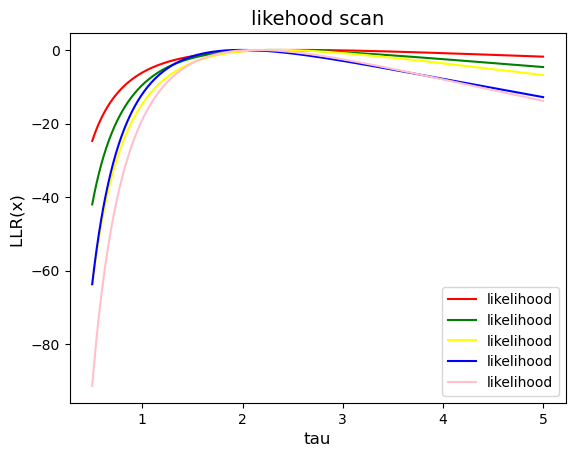

In [30]:
N_min = 10
N_max = 50
fig, ax = plt.subplots()
x = np.linspace( 0.5, 5., 1000)
llr = np.arange(0.,x.size)
colors = ['red', 'green', 'yellow', 'blue', 'pink']
index = 0
while (N_min <= N_max):
    randlist = generate_exp(tau, N_min)
    for i in range(x.size):
        tau_max = sezioneAureaMax_LL(loglikelihood , exp_pdf, randlist, 0.5 , 5.)
        llr[i] = loglikelihood_ratio(x[i], exp_pdf, randlist, tau_max)
    plt.plot( x, llr, color = colors[index], label = 'likelihood' )
    index = index + 1
    N_min = N_min + 10
ax.set_title('likehood scan', size = 14)
ax.set_xlabel('tau', size = 12)
ax.set_ylabel('LLR(x) ', size = 12)
ax.legend()
plt.show()

Exercise 10.6

- Use the bisection method to find the two points τ - στ and τ + στ related to Exercise 1.
- Plot the log-likelihood profile, the estimator values, and the confidence interval along with the horizontal segment used for its determination.


In [31]:
def loglikelihood_ratio(x,pdf,sample,theta):
    return loglikelihood(x,pdf,sample) - loglikelihood(theta,pdf,sample)

In [32]:
from likelihood import intersect_LLR
tau = 3
N = 1000
randlist = generate_exp(tau, N, seed = 0.)
tau_max = sezioneAureaMax_LL (loglikelihood, exp_pdf, randlist, 0.5, 5., 0.0001)    
tau_minusS = intersect_LLR (loglikelihood_ratio, exp_pdf, randlist, 0.5, tau_max, -0.5, tau_max)
tau_plusS = intersect_LLR (loglikelihood_ratio, exp_pdf, randlist, tau_max, 5., -0.5, tau_max)
print('valore che massimizza la ll = ', tau_max)
print('prima intersezione ll = ' + str(tau_minusS) + '\nseconda intersezione ll = ' + str(tau_plusS) )

valore che massimizza la ll =  2.9969146403248383
prima intersezione ll = 2.904027099231211
seconda intersezione ll = 3.093682344315493


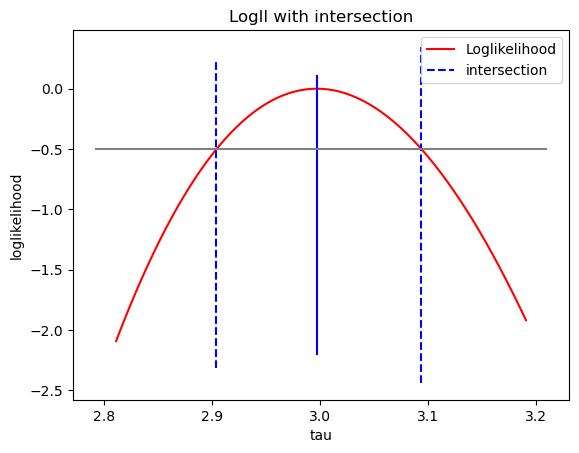

In [33]:
fig, ax = plt.subplots()
x_min = float(tau_minusS - (tau_max - tau_minusS))
x_max = float(tau_plusS + (tau_plusS - tau_max))
x = np.linspace( x_min, x_max, 1000)
y = np.arange( 0., x.size) 
for i in range(x.size) :
    y[i] = loglikelihood_ratio(x[i], exp_pdf, randlist, tau_max)
plt.plot(x,y, color = 'r', label = 'Loglikelihood')
plt.plot([tau_max, tau_max], ax.get_ylim(), color = 'b')
plt.plot([tau_minusS, tau_minusS], ax.get_ylim(), color = 'b', label = 'intersection', linestyle = 'dashed')
plt.plot([tau_plusS, tau_plusS], ax.get_ylim(), color = 'b', linestyle = 'dashed')
plt.plot( ax.get_xlim(), [-0.5, -0.5], color = 'grey')
ax.set_title('Logll with intersection', size = 12)
ax.set_ylabel('loglikelihood', size = 10)
ax.set_xlabel('tau', size = 10)
ax.legend(loc = 'upper right')
plt.show()

Exercise 10.7

Using the toy experiments technique, plot the probability distribution of the τ estimator.
- Overlay the generated histogram with the plot of the estimator and the confidence interval found in the previous exercise.
- Compare the value of στ obtained in the previous exercise with the one calculated from the distribution of the numbers saved in the list.



In [34]:
from stats import stats 
N_toys = 1000
N_event = 50
tau = 3
tau_list = []
for i in range(N_toys):
    randlist = generate_exp(tau, N_event)
    tau_max2 = sezioneAureaMax_LL (loglikelihood, exp_pdf, randlist, 0.5, 5., 0.0001)   
    tau_list.append(tau_max2)

In [35]:
from math import ceil,floor
tau_stats = stats(tau_list)
xMin = ceil(tau_stats.mean() - 4*tau_stats.sigma())
xMax = floor(tau_stats.mean() + 4*tau_stats.sigma())
Nbins = floor(N_toys/20)                                        #attenzione al numero di bins
bins_edges = np.linspace(xMin,xMax,Nbins + 1)

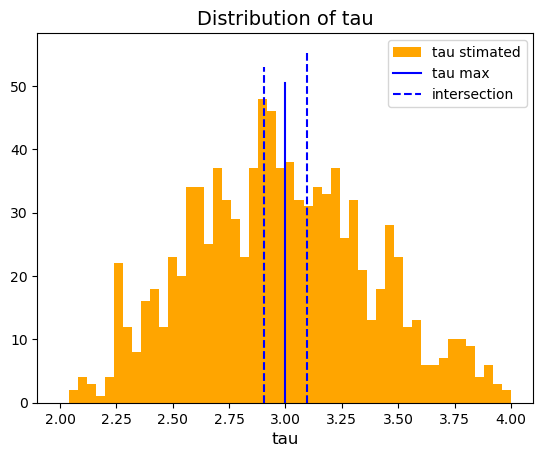

tau max with Ntoys = 2.9975698417875987 +- 0.42837374888476654
tau max with likelihood = 2.9969146403248383 +- 0.09482762254214094


In [36]:
fig, ax = plt.subplots()
ax.hist(tau_list, bins = bins_edges, color = 'orange', label = 'tau stimated')
plt.plot([tau_max, tau_max], ax.get_ylim(), color = 'b', label = 'tau max')
plt.plot([tau_minusS, tau_minusS], ax.get_ylim(), color = 'b', label = 'intersection', linestyle = 'dashed')
plt.plot([tau_plusS, tau_plusS], ax.get_ylim(), color = 'b', linestyle = 'dashed')
ax.set_title('Distribution of tau', size = 14)
ax.set_xlabel('tau', size = 12)
ax.legend(loc = 'upper right')
plt.show()
print('tau max with Ntoys = ' + str(tau_stats.mean()) + ' +- ' + str(tau_stats.sigma()))
print('tau max with likelihood = ' + str(tau_max) + ' +- ' + str(0.5*(tau_plusS-tau_minusS)))

Exercise 10.8

In the asymptotic regime, the distribution of the differences (τ - τtrue) / στ follows a Normal distribution.
- Use the toy experiments method to fill the histogram of the differences, given a number of events per toy experiment.



In [37]:
N_toys = 1000
N_evt = 50
tau_true = 2
diff_list = []
for i in range(N_toys):
    sample_list = generate_exp(tau, N_evt)
    tau_hat = sezioneAureaMax_LL(loglikelihood, exp_pdf, sample_list, 0.5, 5.)
    tau_hat_minusS = intersect_LLR (loglikelihood_ratio, exp_pdf, sample_list, 0.5, tau_hat, -0.5, tau_hat)
    tau_hat_plusS = intersect_LLR (loglikelihood_ratio, exp_pdf, sample_list, tau_hat, 5., -0.5, tau_hat)
    error_tau = 0.5*(tau_hat_plusS - tau_hat_minusS)
    if tau_hat > tau_true :
        diff_list.append ( (tau_hat - tau_true) / error_tau )
    else :
        diff_list.append ( (tau_true - tau_hat) / error_tau )

In [38]:
diff_stats = stats(diff_list)
xmin = ceil(diff_stats.mean() - 5*diff_stats.sigma())
xmax = floor(diff_stats.mean() + 5*diff_stats.sigma())
Nbins = floor(N_toys/20.)
bins_edges = np.linspace( xmin, xmax, Nbins + 1)

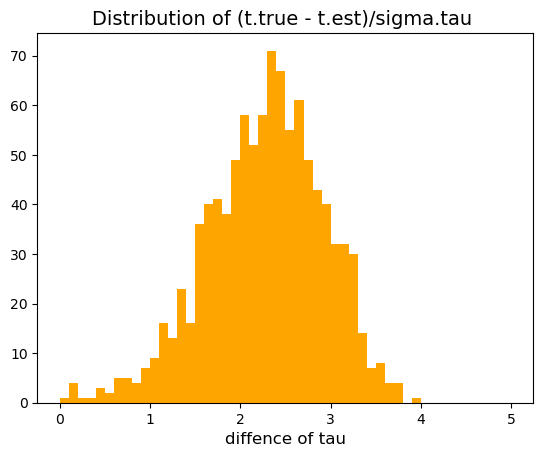

In [39]:
fig, ax = plt.subplots()
ax.hist(diff_list, bins = bins_edges, color = 'orange')
ax.set_title('Distribution of (t.true - t.est)/sigma.tau ', size = 14)
ax.set_xlabel('diffence of tau', size = 12)
plt.show()

- Calculate the mean and sigma of the distribution of differences, and plot their values as a function of the number of events available for estimation, showing the trend on a graph with the number of events available on the horizontal axis and the parameter value on the vertical axis.

In [40]:
N_toys = 10
N_min = 10
N_max = 100
tau_true = 2
N_events = []
sigma_list = []
means_list = []
while (N_min <= N_max) :
    diff_list = []
    for i in range(N_toys) :
        sample_list = generate_exp(tau, N_min)
        tau_hat = sezioneAureaMax_LL(loglikelihood, exp_pdf, sample_list, 0.5, 5.)
        if tau_hat > tau_true :
            diff_list.append (tau_hat - tau_true)
        else :
            diff_list.append (tau_true - tau_hat)
    diff_stats = stats (diff_list)
    means_list.append(diff_stats.mean())
    sigma_list.append(diff_stats.sigma())
    N_events.append(N_min)
    N_min = N_min + 10
print(N_events)

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_ylabel'

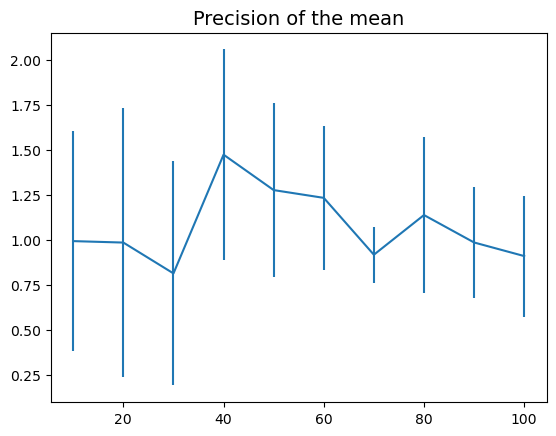

In [41]:
fig, ax = plt.subplots()
ax.errorbar( N_events, means_list, xerr = 0.0, yerr = sigma_list)
plt.title('Precision of the mean', size = 14)
plt.set_ylabel('meand and his uncerty', size = 12)
plt.set_xlabel('N events', size = 12)